Matplotlib is building the font cache; this may take a moment.


=== ADF Test Result for Carbon Intensity ===
ADF Statistic: -11.1360
p-value: 0.0000
Conclusion: Data STASIONER (p <= 0.05)

=== ADF Test Result for Renewable Percentage ===
ADF Statistic: -6.9561
p-value: 0.0000
Conclusion: Data STASIONER (p <= 0.05)



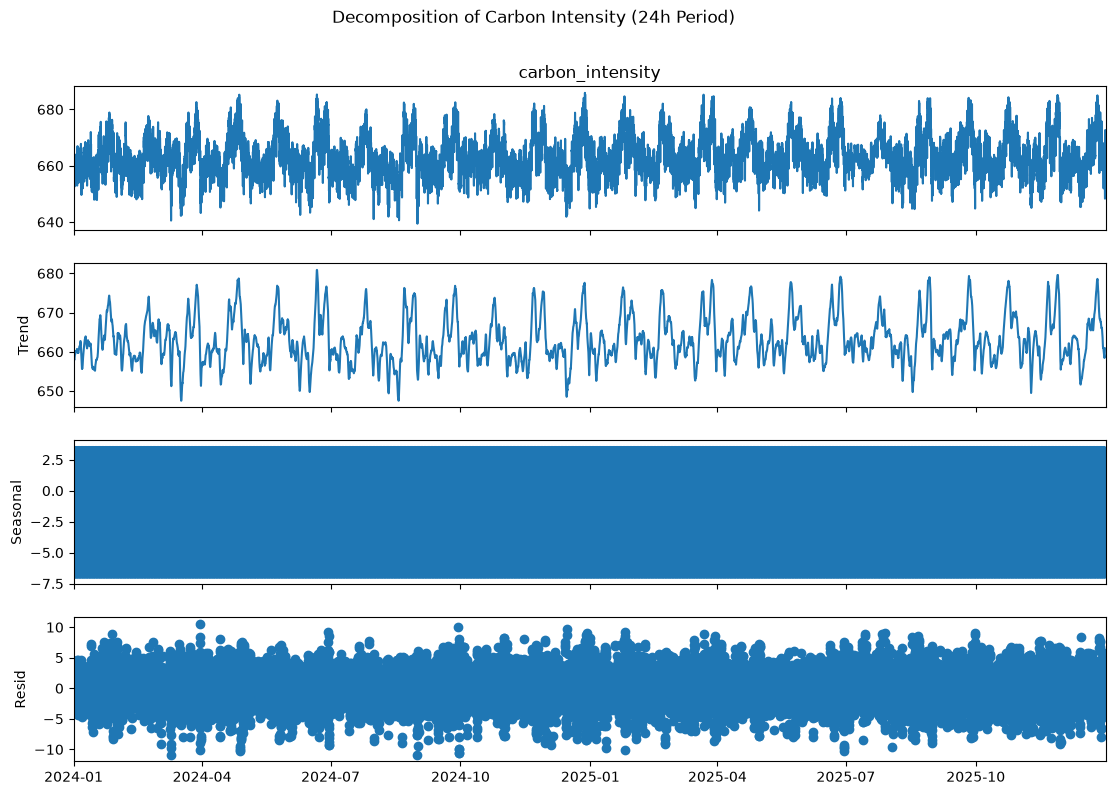

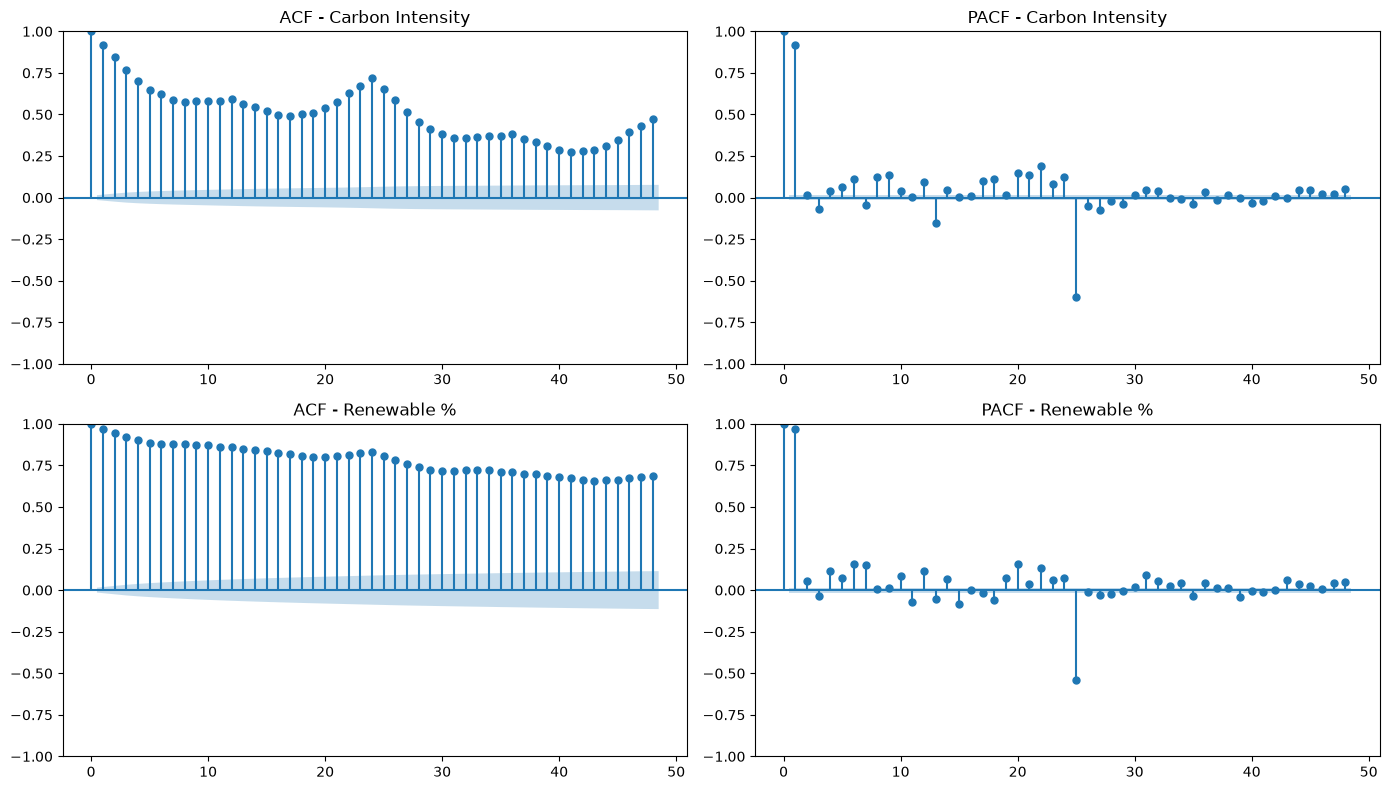

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load Data Processed
df = pd.read_csv("../data/processed/dataset_CI_RE_2024_2025_cleaned.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Uji Stasioneritas (ADF Test)
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f"=== ADF Test Result for {name} ===")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Conclusion: Data STASIONER (p <= 0.05)\n")
    else:
        print("Conclusion: Data TIDAK STASIONER (p > 0.05)\n")

check_stationarity(df['carbon_intensity'], 'Carbon Intensity')
check_stationarity(df['renewable_percentage'], 'Renewable Percentage')

# Dekomposisi Deret Waktu (Siklus 24 Jam)
decomp = seasonal_decompose(df['carbon_intensity'], model='additive', period=24)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Decomposition of Carbon Intensity (24h Period)', y=1.02)
plt.show()

# Plot ACF & PACF (Lag hingga 48 jam)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df['carbon_intensity'], lags=48, ax=axes[0, 0], title='ACF - Carbon Intensity')
plot_pacf(df['carbon_intensity'], lags=48, ax=axes[0, 1], title='PACF - Carbon Intensity')

plot_acf(df['renewable_percentage'], lags=48, ax=axes[1, 0], title='ACF - Renewable %')
plot_pacf(df['renewable_percentage'], lags=48, ax=axes[1, 1], title='PACF - Renewable %')

plt.tight_layout()
plt.show()

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Import TimeSeriesDataLoader dari src
sys.path.append('..')
from src.data_loader import TimeSeriesDataLoader

# Kunci Seed agar hasil reproducible
torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 2. DEFINISI MODEL LSTM
# ==========================================
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1):
        super(LSTMModel, self).__init__()
        # input_dim otomatis menyesuaikan (1 untuk Univariate, 2 Bivariate, 3 Multivariate)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        # Ambil output dari timestep terakhir (look_back ke-24)
        out = self.fc(out[:, -1, :])
        return out

# ==========================================
# 3. HELPER EKS PERIMEN
# ==========================================
def run_experiment(exp_name, feature_cols, df, loader, look_back=24, epochs=25, batch_size=32):
    print(f"\n=================== Running: {exp_name} ===================")
    print(f"Fitur Digunakan ({len(feature_cols)}): {feature_cols}")

    # A. Split & Scaling
    scaled_train_df, scaled_test_df = loader.split_and_scale(df, feature_cols)

    # B. Create Sliding Window
    X_train, y_train = loader.create_sliding_window(scaled_train_df, look_back=look_back)
    X_test, y_test = loader.create_sliding_window(scaled_test_df, look_back=look_back)

    # C. Convert ke PyTorch Tensors & DataLoader
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # D. Inisialisasi Model, Loss, Optimizer
    input_dim = len(feature_cols)
    model = LSTMModel(input_dim=input_dim, hidden_dim=64, num_layers=2)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # E. Training Loop
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Loss: {total_loss / len(train_loader):.5f}")

    # F. Prediksi & Inverse Transform ke Skala Asli (gCO₂eq/kWh)
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_t).numpy()

    # Inverse scale menggunakan target_scaler dari data_loader
    preds_actual = loader.target_scaler.inverse_transform(preds_scaled)
    y_test_actual = loader.target_scaler.inverse_transform(y_test)

    # G. Hitung Metrik Evaluasi
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
    mae = mean_absolute_error(y_test_actual, preds_actual)

    print(f"[{exp_name} Result] RMSE: {rmse:.3f} | MAE: {mae:.3f}")

    return {
        'name': exp_name,
        'rmse': rmse,
        'mae': mae,
        'preds': preds_actual,
        'actuals': y_test_actual
    }

# ==========================================
# 4. EKSEKUSI TIGA SKENARIO
# ==========================================
data_path = '../data/processed/dataset_CI_RE_2024_2025_cleaned.csv'  # sesuaikan nama/path file CSV-mu
loader = TimeSeriesDataLoader()
df = loader.load_and_clean(data_path)

# Skenario Fitur
target_col = 'carbon_intensity'
re_col = 'renewable_percentage'

experiments = {
    'Univariate': [target_col],
    'Bivariate': [target_col, re_col]
}

results = []
for exp_name, feature_cols in experiments.items():
    res = run_experiment(exp_name, feature_cols, df, loader, look_back=24, epochs=25)
    results.append(res)

Loading data from ../data/processed/dataset_CI_RE_2024_2025_cleaned.csv...


KeyError: 'Datetime (UTC)'